### Title - Transcriptomic response of yeast to Clioquinol treatment reveals perturbation of metal homeostasis and stress-associated pathways

### 1. Reseach Question
    - How does Clioquinol (a known metal chelator) alter global gene expression in yeast compared to DMSO control?

    -Clioquinol is known to chelate copper and zinc. In yeast, metal homeostasis is tightly linked to:
        -mitochondrial function
        -oxidative stress
        -central metabolism

    -A transcriptome-wide response allows us to test whether the expected biology is visible at the gene-expression level.

### 2. Dataset and experimental design

    Dataset: GSE99884
        Page url = https://www.ncbi.nlm.nih.gov/geo/query/acc.cgi?acc=GSE99884
        Dataset url = https://docs.google.com/spreadsheets/d/1-fV9FstrFWJudYp7J4HsDiU7kDIaJS5M/edit?usp=sharing&ouid=109885149967876615001&rtpof=true&sd=true
    Organism: Saccharomyces cerevisiae
    Technology: RNA-seq
    Samples used:

    DMSO_rep1, DMSO_rep2 (control); CQ_rep1, CQ_rep2 (Clioquinol)

    Other conditions (11, 10{3,3,1}) were excluded to maintain a clean, interpretable comparison under time constraints.

### 3. Data preprocessing and metadata

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_excel('GSE99884_Counts_raw_And_DESeq.xlsx')
df = df.set_index('feature.IDs')
df

,DMSO_rep1_raw,DMSO_rep2_raw,CQ_rep1_raw,CQ_rep2_raw,11_rep1_raw,11_rep2_raw,"10{3,3,1}_rep1_raw","10{3,3,1}_rep2_raw"
feature.IDs,,,,,,,,
15S_rRNA,31,18,38,37,32,21,20,25
21S_rRNA,135,48,98,72,110,83,107,98
HRA1,0,0,0,2,0,0,0,0
ICR1,389,213,263,247,202,237,179,236
LSR1,104,53,257,204,71,94,56,66
...,...,...,...,...,...,...,...,...
tY(GUA)M1,0,0,0,0,0,0,0,0
tY(GUA)M2,0,0,0,0,0,0,0,0
tY(GUA)O,0,0,0,0,0,0,0,0


In [3]:
df = df[df.sum(axis = 1) > 0]    # dropping rows with sum=0
df.drop(columns=['11_rep1_raw', '11_rep2_raw', '10{3,3,1}_rep1_raw', '10{3,3,1}_rep2_raw'], inplace=True)    #removing some columns to reduce complexity
df

C:\Users\Kishore\AppData\Local\Temp\ipykernel_34560\1351664209.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df.drop(columns=['11_rep1_raw', '11_rep2_raw', '10{3,3,1}_rep1_raw', '10{3,3,1}_rep2_raw'], inplace=True)    #removing some columns to reduce complexity


,DMSO_rep1_raw,DMSO_rep2_raw,CQ_rep1_raw,CQ_rep2_raw
feature.IDs,,,,
15S_rRNA,31,18,38,37
21S_rRNA,135,48,98,72
HRA1,0,0,0,2
ICR1,389,213,263,247
LSR1,104,53,257,204
...,...,...,...,...
snR85,7,2,2,2
snR86,298,192,330,219
snR87,12,8,6,10


In [4]:
sample_names = df.columns.tolist()

condition = []
replicate = []
for sample in sample_names:
    if 'dmso' in sample.lower():
        condition.append('DMSO')
    elif 'cq' in sample.lower():
        condition.append('Clioquinol')
    else:
        condition.append('unknown')

for sample in sample_names:
    if 'rep1' in sample.lower():
        replicate.append('1')
    elif 'rep2' in sample.lower():
        replicate.append('2')
    else:
        replicate.append('unknown') 


# Create coldata: samples as rows
meta_data = pd.DataFrame({
    'sample': sample_names,
    'condition': pd.Categorical(condition, categories=['DMSO', 'Clioquinol']),
    'replicate': pd.Categorical(replicate, categories=['1', '2']),
}).set_index('sample')

print(meta_data)

                condition replicate
sample                             
DMSO_rep1_raw        DMSO         1
DMSO_rep2_raw        DMSO         2
CQ_rep1_raw    Clioquinol         1
CQ_rep2_raw    Clioquinol         2


In [5]:
from pydeseq2.dds import DeseqDataSet
from pydeseq2.ds import DeseqStats

In [6]:
df1 = df.T
dds = DeseqDataSet(counts=df1,
            metadata=meta_data,
            design_factors="condition")

C:\Users\Kishore\AppData\Local\Temp\ipykernel_34560\241504898.py:2: DeprecationWarning: design_factors is deprecated and will soon be removed.Please consider providing a formulaic formula using the design argumentinstead.
  dds = DeseqDataSet(counts=df1,


In [7]:
dds.deseq2()

Fitting size factors...
... done in 0.01 seconds.



Using None as control genes, passed at DeseqDataSet initialization


Fitting dispersions...
... done in 3.74 seconds.

Fitting dispersion trend curve...
... done in 0.36 seconds.

C:\Users\Kishore\AppData\Local\Programs\Python\Python312\Lib\site-packages\pydeseq2\dds.py:548: UserWarning: As the residual degrees of freedom is less than 3, the distribution of log dispersions is especially asymmetric and likely to be poorly estimated by the MAD.
  self.fit_dispersion_prior()
Fitting MAP dispersions...
... done in 4.08 seconds.

Fitting LFCs...
... done in 2.22 seconds.

Calculating cook's distance...
... done in 0.01 seconds.

Replacing 0 outlier genes.



In [8]:
sample_names_2 = df1.columns.tolist()
norm_counts = dds.layers['normed_counts']
normalised_lib = pd.DataFrame(norm_counts, columns=sample_names_2)
normalised_lib = normalised_lib.T
normalised_lib.columns = sample_names
#normalised_lib.to_csv('normalised_lib.csv')
normalised_lib   # this is the dataframe normalising raw counts

,DMSO_rep1_raw,DMSO_rep2_raw,CQ_rep1_raw,CQ_rep2_raw
15S_rRNA,26.962037,22.670373,32.629492,39.834059
21S_rRNA,117.415324,60.454327,84.149743,77.514926
HRA1,0.000000,0.000000,0.000000,2.153192
ICR1,338.330081,268.266077,225.830432,265.919262
LSR1,90.453286,66.751653,220.678407,219.625625
...,...,...,...,...
snR85,6.088202,2.518930,1.717342,2.153192
snR86,259.183455,241.817309,283.361379,235.774568
snR87,10.436918,10.075721,5.152025,10.765962
snR9,15.655376,12.594651,3.434683,7.536173


### Raw counts were reserved for statistical inference, while log-normalized counts were used exclusively for exploratory analyses such as PCA and correlation.

### 4. Quality control and exploratory analysis

### 4.1 Sample–sample correlation

In [9]:
log_norm_expr = np.log2(normalised_lib + 1)  #Log2 transformation is applied to reduce highly expressed genes and stabilize variance and +1 is added to overcome log(0).
# Compute sample–sample correlation
corr_matrix = log_norm_expr.corr(method="pearson")
corr_matrix

,DMSO_rep1_raw,DMSO_rep2_raw,CQ_rep1_raw,CQ_rep2_raw
DMSO_rep1_raw,1.000000,0.993226,0.967458,0.974261
DMSO_rep2_raw,0.993226,1.000000,0.971118,0.976291
CQ_rep1_raw,0.967458,0.971118,1.000000,0.987133
CQ_rep2_raw,0.974261,0.976291,0.987133,1.000000


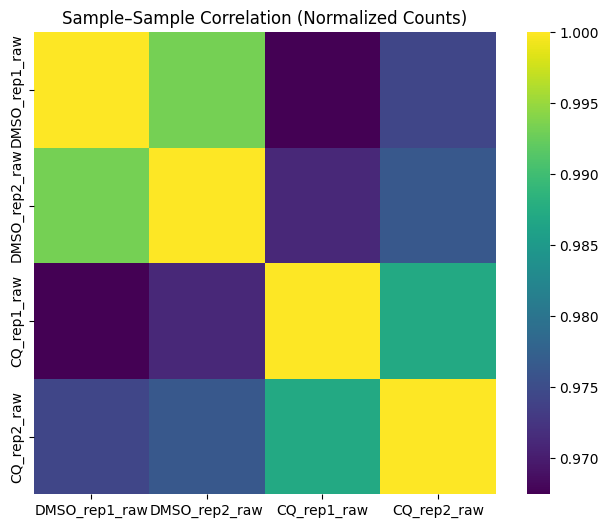

In [10]:
plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, cmap="viridis", square=True)
plt.title("Sample–Sample Correlation (Normalized Counts)")
plt.show()

### From the above heatmap we can tell CQ_rep1_raw, CQ_rep2_raw are less correlated with DMSO_rep1_raw, DMSO_rep2_raw

### 4.2 PCA (Principal Component Analysis)

In [11]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

# Transpose: samples as rows, genes as columns
X = log_norm_expr.T

# Scale features
X_scaled = StandardScaler().fit_transform(X)

# PCA
pca = PCA(n_components=2)
pcs = pca.fit_transform(X_scaled)

# Create PCA dataframe
pca_df = pd.DataFrame(
    pcs,
    columns=["PC1", "PC2"],
    index=X.index
)

In [12]:
conditions = {
    "DMSO": "DMSO",
    "CQ": "Clioquinol"
}

pca_df["Condition"] = [
    "Clioquinol" if "CQ" in s else "DMSO" for s in pca_df.index
]

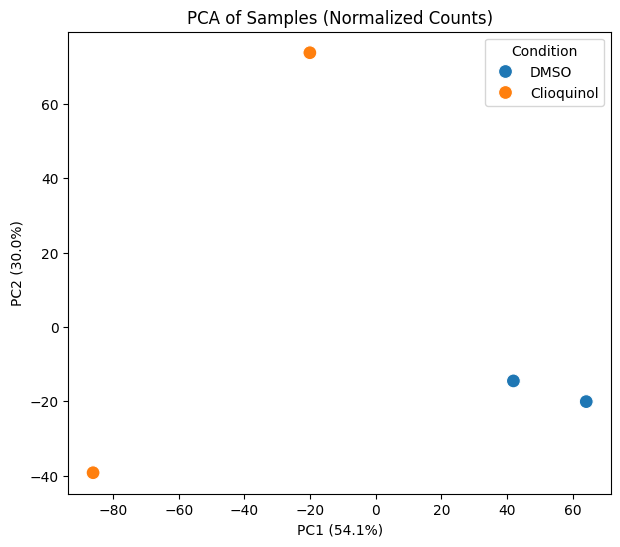

In [13]:
plt.figure(figsize=(7, 6))
sns.scatterplot(
    data=pca_df,
    x="PC1",
    y="PC2",
    hue="Condition",
    s=100
)

plt.xlabel(f"PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)")
plt.ylabel(f"PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)")
plt.title("PCA of Samples (Normalized Counts)")
plt.show()


### This shows DMSO_rep1_raw, DMSO_rep2_raw are closely correlated but CQ_rep1_raw, CQ_rep2_raw are not closely correlated on PC2 plane
    (mostly we check PC1 more than PC2[check SCREE plot])

### 5. Differential expression analysis

In [14]:
stat_res = DeseqStats(dds, n_cpus=8, contrast = ('condition','DMSO', 'Clioquinol'))
stat_res.summary()

Running Wald tests...


Log2 fold change & Wald test p-value: condition DMSO vs Clioquinol
               baseMean  log2FoldChange     lfcSE      stat    pvalue  \
feature.IDs                                                             
15S_rRNA      30.523990       -0.538539  0.622681 -0.864871  0.387109   
21S_rRNA      84.883580        0.147589  0.443017  0.333145  0.739025   
HRA1           0.538298       -2.469824  5.238523 -0.471473  0.637303   
ICR1         274.586463        0.306872  0.285703  1.074094  0.282781   
LSR1         149.377243       -1.477144  0.343031 -4.306155  0.000017   
...                 ...             ...       ...       ...       ...   
snR85          3.119417        1.175879  1.843404  0.637885  0.523549   
snR86        255.034178       -0.051745  0.283663 -0.182417  0.855256   
snR87          9.107656        0.378614  1.100492  0.344040  0.730816   
snR9           9.805221        1.386277  1.088463  1.273610  0.202802   
tS(CGA)C       0.214668       -1.274312  5.353191 -0.2380

... done in 2.47 seconds.



### PyDESeq2 requires raw counts as input because its underlying negative binomial model needs unnormalized integer read counts to accurately estimate dispersion, mean-variance relationships, and normalization factors internally.

### DESeq2 results tables
    baseMean
        Average normalized expression across all samples for the gene. Higher values indicate more reliable fold change estimates.

    log2FoldChange
        Log base-2 of the fold change in expression between conditions (positive = upregulation, negative = downregulation, 0 = no change). Makes up- and downregulation symmetric for analysis.

    lfcSE
        Standard error of the log2FoldChange estimate, reflecting variability or uncertainty in the fold change.

    stat
        Test statistic (Wald statistic: log2FoldChange divided by lfcSE), used to compute the p-value.

    pvalue
        Raw p-value from the Wald test, probability of observing the data (or more extreme) assuming no differential expression.

    padj
        P-value adjusted for multiple testing (Benjamini-Hochberg), controls false discovery rate; typically use padj < 0.05 for significance.

In [15]:
res = stat_res.results_df
#res = res[res.baseMean >= 10]
#sigs = res[(res.padj < 0.05) & (abs(res.log2FoldChange) > 0.5)]
res

,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj
feature.IDs,,,,,,
15S_rRNA,30.523990,-0.538539,0.622681,-0.864871,0.387109,0.700131
21S_rRNA,84.883580,0.147589,0.443017,0.333145,0.739025,0.906196
HRA1,0.538298,-2.469824,5.238523,-0.471473,0.637303,NaN
ICR1,274.586463,0.306872,0.285703,1.074094,0.282781,0.603739
LSR1,149.377243,-1.477144,0.343031,-4.306155,0.000017,0.000288
...,...,...,...,...,...,...
snR85,3.119417,1.175879,1.843404,0.637885,0.523549,0.791507
snR86,255.034178,-0.051745,0.283663,-0.182417,0.855256,0.954754
snR87,9.107656,0.378614,1.100492,0.344040,0.730816,0.900516


In [16]:
import gseapy as gp
from gseapy.plot import gseaplot

In [17]:
res['symbol'] = sample_names_2
res = res.drop_duplicates()
ranking = res[['symbol', 'stat']].dropna().sort_values('stat', ascending = False)
ranking

,symbol,stat
feature.IDs,,
YOR065W,YOR065W,24.844431
YGL009C,YGL009C,22.171286
YLL041C,YLL041C,21.931201
YNL111C,YNL111C,21.745504
YOR356W,YOR356W,20.796425
...,...,...
YLR136C,YLR136C,-25.341716
YOL158C,YOL158C,-25.808635
YHL047C,YHL047C,-31.633372


In [18]:
from sanbomics.plots import volcano

0s encountered for p value, imputing 1e-323
impute your own value if you want to avoid this


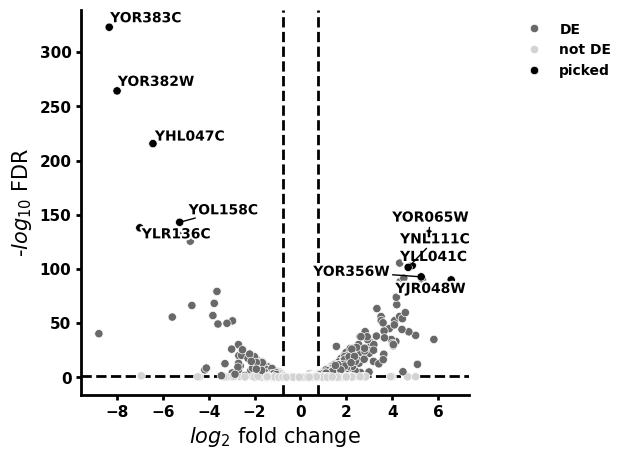

In [19]:
volcano(res, symbol='symbol')

### Top left shows downregulation and Top right shows upregulation

In [20]:
ranked_genes = res[["symbol", "log2FoldChange"]]
#print(ranked_genes)
sample_names_3 = ranked_genes['symbol']
ranked_genes = ranked_genes.set_index("symbol")["log2FoldChange"]
ranked_genes = res[['symbol', 'log2FoldChange']].dropna().sort_values('log2FoldChange', ascending = False)
ranked_genes

,symbol,log2FoldChange
feature.IDs,,
YJR048W,YJR048W,6.574278
YDR119W-A,YDR119W-A,5.820315
YOR065W,YOR065W,5.597376
YEL024W,YEL024W,5.327468
YOR356W,YOR356W,5.266718
...,...,...
YJR005C-A,YJR005C-A,-6.943966
YLR136C,YLR136C,-7.006717
YOR382W,YOR382W,-8.000111


### 6. GSEA Enrichment scores

In [21]:
import gseapy as gp
gp.get_library_name(organism='Yeast')

['Cellular_Component_AutoRIF',
 'Cellular_Component_AutoRIF_Predicted_zscore',
 'GO_Biological_Process_2018',
 'GO_Biological_Process_AutoRIF',
 'GO_Biological_Process_AutoRIF_Predicted_zscore',
 'GO_Cellular_Component_2018',
 'GO_Cellular_Component_AutoRIF',
 'GO_Cellular_Component_AutoRIF_Predicted_zscore',
 'GO_Molecular_Function_2018',
 'GO_Molecular_Function_AutoRIF',
 'GO_Molecular_Function_AutoRIF_Predicted_zscore',
 'Gene_Interaction_Hubs_BioGRID_2018',
 'InterPro_Domains_2019',
 'KEGG_2018',
 'KEGG_2019',
 'PPI_Hubs_BioGRID_2018',
 'Pfam_Domains_2019',
 'Phenotype_AutoRIF',
 'Phenotype_AutoRIF_Predicted_zscore',
 'TF2DNA_2018',
 'WikiPathways_2018']

In [22]:
ranked_genes_noNulls = ranked_genes.dropna(how='all')
ranked_genes_noNulls.drop_duplicates()
ranked_genes_noNulls

,symbol,log2FoldChange
feature.IDs,,
YJR048W,YJR048W,6.574278
YDR119W-A,YDR119W-A,5.820315
YOR065W,YOR065W,5.597376
YEL024W,YEL024W,5.327468
YOR356W,YOR356W,5.266718
...,...,...
YJR005C-A,YJR005C-A,-6.943966
YLR136C,YLR136C,-7.006717
YOR382W,YOR382W,-8.000111


In [23]:
manual_set = {'things':['YJR048W','YDR119W-A','YOR065W','YEL024W','YOR356W']}
pre_res = gp.prerank(rnk = ranked_genes_noNulls,
                     gene_sets = ['Cellular_Component_AutoRIF',
 'Cellular_Component_AutoRIF_Predicted_zscore',
 'GO_Biological_Process_2018',
 'GO_Biological_Process_AutoRIF',
 'GO_Biological_Process_AutoRIF_Predicted_zscore',
 'GO_Cellular_Component_2018',
 'GO_Cellular_Component_AutoRIF',
 'GO_Cellular_Component_AutoRIF_Predicted_zscore',
 'GO_Molecular_Function_2018',
 'GO_Molecular_Function_AutoRIF',
 'GO_Molecular_Function_AutoRIF_Predicted_zscore',
 'Gene_Interaction_Hubs_BioGRID_2018',
 'InterPro_Domains_2019',
 'KEGG_2018',
 'KEGG_2019',
 'PPI_Hubs_BioGRID_2018',
 'Pfam_Domains_2019',
 'Phenotype_AutoRIF',
 'Phenotype_AutoRIF_Predicted_zscore',
 'TF2DNA_2018',
 'WikiPathways_2018', manual_set],
                     seed = 6, permutation_num = 100, min_size=1)

2026-01-28 13:13:24,422 [WARNING] Duplicated values found in preranked stats: 3.81% of genes
The order of those genes will be arbitrary, which may produce unexpected results.
2026-01-28 13:13:27,073 [ERROR] No supported gene_sets: Cellular_Component_AutoRIF
2026-01-28 13:13:30,180 [ERROR] No supported gene_sets: Cellular_Component_AutoRIF_Predicted_zscore
2026-01-28 13:13:32,679 [ERROR] No supported gene_sets: GO_Biological_Process_2018
2026-01-28 13:13:35,369 [ERROR] No supported gene_sets: GO_Biological_Process_AutoRIF
2026-01-28 13:13:38,987 [ERROR] No supported gene_sets: GO_Biological_Process_AutoRIF_Predicted_zscore
2026-01-28 13:13:42,823 [ERROR] No supported gene_sets: GO_Cellular_Component_2018
2026-01-28 13:13:46,080 [ERROR] No supported gene_sets: GO_Cellular_Component_AutoRIF
2026-01-28 13:13:49,020 [ERROR] No supported gene_sets: GO_Cellular_Component_AutoRIF_Predicted_zscore
2026-01-28 13:13:52,006 [ERROR] No supported gene_sets: GO_Molecular_Function_2018
2026-01-28 13:1

In [24]:
out = []

for term in list(pre_res.results):
    out.append([term,
               pre_res.results[term]['fdr'],
               pre_res.results[term]['es'],
               pre_res.results[term]['nes']])

out_df = pd.DataFrame(out, columns = ['Term','fdr', 'es', 'nes']).sort_values('fdr').reset_index(drop = True)
out_df

,Term,fdr,es,nes
0,21__things,0.000000,1.000000,1.752320
1,Pfam_Domains_2019__NDK,0.789062,-0.600095,-0.795048
2,InterPro_Domains_2019__Nucleoside diphosphate ...,0.789062,-0.600095,-0.795048


In [25]:
out_df.sort_values('nes').iloc[0].Term

'Pfam_Domains_2019__NDK'

[<Axes: xlabel='Gene Rank'>, <Axes: ylabel='Enrichment Score'>]

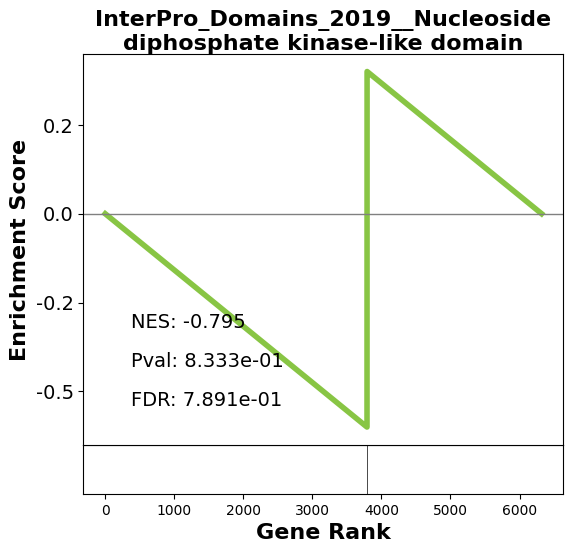

In [26]:
gseaplot(#pre_res.ranking,
         term = 'InterPro_Domains_2019__Nucleoside diphosphate kinase-like domain',
         **pre_res.results['InterPro_Domains_2019__Nucleoside diphosphate kinase-like domain'])

### GO(GeneOncology) databases are:
        -much richer for human
        -more limited for yeast
    Due to that limitation we get only 2 gene_sets 'InterPro_Domains_2019__Nucleoside diphosphate kinase-like domain' and 'Pfam_Domains_2019__NDK'.

    But as we see, 'InterPro_Domains_2019__Nucleoside diphosphate kinase-like domain' revealed overrepresentation of nucleoside diphosphate kinase–related domains, suggesting perturbation of nucleotide and energy homeostasis.

### What NDPK actually does:
    Catalyze: NDP + ATP <-> NTP + ADP
    In yeast, NDPKs respond strongly to:
        -metabolic stress
        -mitochondrial dysfunction
        -oxidative conditions
### Why Clioquinol would trigger this specifically:
    Chelates copper and zinc.
    Copper is required for:
        -cytochrome c oxidase
        -mitochondrial respiration
    Zinc is required for:
        -transcription factors
        -enzyme structure

### So metal chelation → impaired respiration → ATP imbalance → nucleotide pool imbalance.
### Metal chelation → mitochondrial stress → energy imbalance → nucleotide buffering response

### The transcriptional response suggests perturbation of nucleotide and energy homeostasis.

### 7. CONCLUSION:
    Transcriptomic analysis of yeast cells treated with Clioquinol reveals a focused and coherent adaptive response rather than broad transcriptional reprogramming. Exploratory analyses indicate treatment-associated variation, while functional enrichment highlights overrepresentation of nucleoside diphosphate kinase–related domains. This suggests modulation of nucleotide buffering and energy homeostasis, consistent with secondary metabolic stress arising from metal chelation–induced mitochondrial perturbation. The absence of extensive GO Biological Process enrichment likely reflects the narrow, compensatory nature of the response and dataset size rather than lack of biological signal. Overall, the results support a model in which Clioquinol induces constrained metabolic stress, eliciting targeted molecular adaptations rather than nonspecific toxicity.